In [1]:
# Import functions from the updated SPAC package
from spac.data_utils import load_csv_files, select_values, combine_dfs, ingest_cells 
from spac.transformations import arcsinh_transformation, z_score_normalization, run_umap, phenograph_clustering
from spac.visualization import boxplot, histogram, hierarchical_heatmap, dimensionality_reduction_plot, spatial_plot, sankey_plot, visualize_nearest_neighbor, plot_ripley_l
from spac.spatial_analysis import spatial_interaction, calculate_nearest_neighbor, ripley_l
from spac.phenotyping import assign_manual_phenotypes
from spac.transformations import rename_annotations
from spac.leiden_clustering import preprocess, leiden_only_clustering, plot
from functools import partial

import numpy as np
import pandas as pd
from math import ceil, sqrt
import matplotlib.pyplot as plt
import seaborn as sns 
import copy
import anndata
import scanpy as sc
import plotly.io as pio
from PIL import Image as PILImage
from pprint import pprint
from io import BytesIO
%matplotlib inline

# Reduce verbosity settings
import warnings
warnings.filterwarnings('ignore')

# Configure root logger to suppress INFO
# Set logging to only show warnings and errors
import logging
import sys
logging.getLogger().setLevel(logging.WARNING)

# Configure specific loggers
logging.getLogger('spac').setLevel(logging.WARNING)
logging.getLogger('spac.utils').setLevel(logging.WARNING)  # In case of sub-loggers
logging.getLogger('spac.visualization').setLevel(logging.WARNING)

# Also disable propagation to root logger
logging.getLogger('spac').propagate = False

# For scanpy verbosity
sc.settings.verbosity = 1  # Only show errors
# Set visualization parameters
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Suppress matplotlib debug messages
logging.getLogger('matplotlib').setLevel(logging.WARNING)

/home/x-rprasanna/.local/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/x-rprasanna/.local/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/x-rprasanna/.local/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
2026-03-31 15:17:26.252611: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774984646.420639    1802 cuda_dnn.cc:8579] Unable to register cuDNN factory:

In [2]:
# Setup working directory and file paths
data_csv = "../paper/examples/example_lymphnode_data.csv"

In [3]:
def generate_grid_frame(adata, fig_width=12, fig_height=12, dpi=300, n_plots=None):
    """Generate a grid frame for multiple subplots."""
    if n_plots is None:
        n_annotations = len(adata.obs.columns.tolist())
    else:
        n_annotations = n_plots
    
    n_cols = ceil(sqrt(n_annotations))
    n_rows = ceil(n_annotations / n_cols)
    
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(fig_width, fig_height),
        dpi=dpi
    )
    axes = axes.flatten()
    return fig, axes

In [4]:
# Load data without verbose output
import io
import contextlib

file_names = [data_csv]

# Suppress all output from load_csv_files
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    data = load_csv_files(file_names)

# Get the dataframe
df = data[0] if isinstance(data, list) else data

# Print only your custom summary
print(f"✓ Dataset loaded: {df.shape[0]} cells × {df.shape[1]} features")
print(f"✓ Marker columns: {sum(col not in ['CellID', 'X_centroid', 'Y_centroid'] for col in df.columns)} markers")

✓ Dataset loaded: 4825 cells × 85 features
✓ Marker columns: 82 markers


In [5]:
# Define the manual phenotype codes and names
phenotype_definitions = pd.DataFrame([
    {"phenotype_code": "CD3D+CD4+FOXP3+", "phenotype_name": "Regulatory T Cell"},
    {"phenotype_code": "CD3D+CD4+", "phenotype_name": "Helper T Cell"},
    {"phenotype_code": "CD3D+CD8A+", "phenotype_name": "Cytotoxic T Cell"},
    {"phenotype_code": "CD3D+", "phenotype_name": "T Cell"},
    {"phenotype_code": "CD20+", "phenotype_name": "B Cell"},
    {"phenotype_code": "CD21+CD20-", "phenotype_name": "Follicular Dendritic Cell"},
    {"phenotype_code": "CD56+", "phenotype_name": "NK Cell"},
    {"phenotype_code": "CD68+", "phenotype_name": "CD68+ Macrophage"},
    {"phenotype_code": "CD11C+", "phenotype_name": "Dendritic Cell"},
    {"phenotype_code": "CD15+", "phenotype_name": "Granulocyte"},
    {"phenotype_code": "KI67+", "phenotype_name": "Proliferating Cell"},
    {"phenotype_code": "PD1+", "phenotype_name": "Activated T/B Cell"},
    {"phenotype_code": "HLADR+", "phenotype_name": "Activated APC"},
    {"phenotype_code": "CD163+", "phenotype_name": "CD163+ Macrophage"}
])

# Apply manual phenotyping with suppressed output
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    assign_manual_phenotypes(df, phenotype_definitions, suffix="_expression")
    
# Print custom output
print("✓ Manual phenotypes assigned successfully!")
print(f"  - Added {len(phenotype_definitions)} phenotype definitions")
print(f"  - Processed {len(df)} cells")

✓ Manual phenotypes assigned successfully!
  - Added 14 phenotype definitions
  - Processed 4825 cells


In [6]:
# Define features to include in analysis
feature_names = [
    "CD25", "CD2", "CD10", "CD163", "CD3D", "CD5", "CD30", "ACTIN", "CD45",
    "CD206", "CD68", "PD1", "KI67", "CD11C", "CD7", "CD8A", "FOXP3", "CD20",
    "CD4", "HLADR", "PSTAT3", "PS6", "PERK", "CD21", "CD43", "NOS2", "PDL1",
    "CD11B", "CD57", "MHCI", "CD15", "ASMA", "CD56"
]

# Create regex patterns for feature selection
regex_str = [f"^{feature}$" for feature in feature_names]

# Define spatial coordinates and annotations
x_col = "X_centroid"
y_col = "Y_centroid"
annotation = ["broad_cell_type", "detailed_cell_type", "manual_phenotype"]

# Create AnnData object
adata = ingest_cells(
    dataframe=df,
    regex_str=regex_str,
    x_col=x_col,
    y_col=y_col,
    annotation=annotation
)

print(f"AnnData object created: {adata}")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of features: {adata.n_vars}")

^CD25$
^CD2$
^CD10$
^CD163$
^CD3D$
^CD5$
^CD30$
^ACTIN$
^CD45$
^CD206$
^CD68$
^PD1$
^KI67$
^CD11C$
^CD7$
^CD8A$
^FOXP3$
^CD20$
^CD4$
^HLADR$
^PSTAT3$
^PS6$
^PERK$
^CD21$
^CD43$
^NOS2$
^PDL1$
^CD11B$
^CD57$
^MHCI$
^CD15$
^ASMA$
^CD56$
AnnData object created: AnnData object with n_obs × n_vars = 4825 × 33
    obs: 'broad_cell_type', 'detailed_cell_type', 'manual_phenotype'
    obsm: 'spatial'
Number of cells: 4825
Number of features: 33


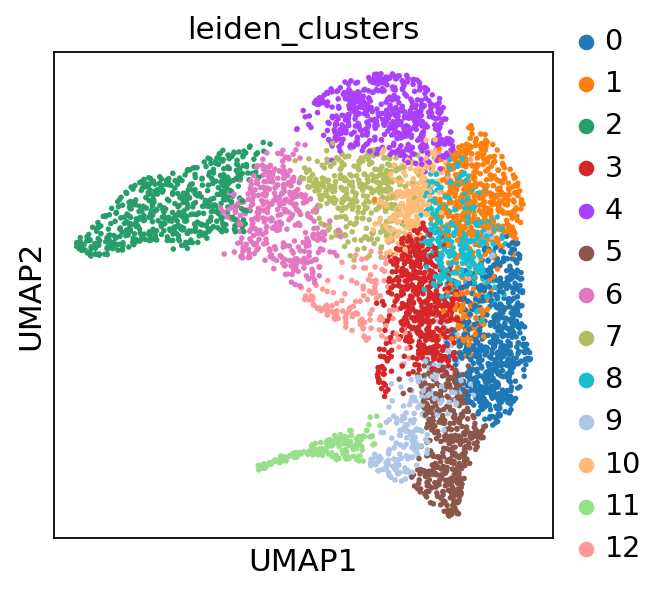

In [7]:
ad = preprocess(adata)
ad = leiden_only_clustering(ad)
plot(ad)

In [8]:
# Test 1: Basic default run (original behavior unchanged)
ad = preprocess(adata)
ad = leiden_only_clustering(ad)
assert "leiden_clusters" in ad.obs.columns, "Default key_added failed"
assert ad.obs["leiden_clusters"].notna().all(), "Some cells have no cluster"
print(f"✓ Basic run: {ad.obs['leiden_clusters'].nunique()} clusters found")

✓ Basic run: 13 clusters found


In [ ]:
# Test 2: Resolution affects number of clusters
ad_low = leiden_only_clustering(preprocess(adata), resolution=0.1)
ad_high = leiden_only_clustering(preprocess(adata), resolution=2.0)
n_low = ad_low.obs["leiden_clusters"].nunique()
n_high = ad_high.obs["leiden_clusters"].nunique()
assert n_low < n_high, f"Higher resolution should produce more clusters: low={n_low}, high={n_high}"
print(f"✓ Resolution test: low={n_low} clusters, high={n_high} clusters")

In [ ]:
# Test 3: Same random_state produces same clusters
ad_prep = preprocess(adata)
ad_r1 = leiden_only_clustering(ad_prep, random_state=42)
ad_r2 = leiden_only_clustering(ad_prep, random_state=42)
assert (ad_r1.obs["leiden_clusters"] == ad_r2.obs["leiden_clusters"]).all(), "Same seed gave different results"
print("✓ Reproducibility test passed: same random_state gives same clusters")

In [ ]:
# Test 4: Different random_state may give different clusters
ad_prep = preprocess(adata)
ad_s1 = leiden_only_clustering(ad_prep, random_state=0)
ad_s2 = leiden_only_clustering(ad_prep, random_state=99)
same = (ad_s1.obs["leiden_clusters"] == ad_s2.obs["leiden_clusters"]).all()
print(f"✓ Different random_state gives same result: {same} (may vary by dataset)")

In [ ]:
# Test 5: n_iterations runs without error
ad_prep = preprocess(adata)
ad_iter = leiden_only_clustering(ad_prep, n_iterations=2)
assert "leiden_clusters" in ad_iter.obs.columns, "n_iterations run failed"
print(f"✓ n_iterations=2 run: {ad_iter.obs['leiden_clusters'].nunique()} clusters")

In [ ]:
# Test 6: Custom key_added
ad_prep = preprocess(adata)
ad_key = leiden_only_clustering(ad_prep, key_added="my_clusters")
assert "my_clusters" in ad_key.obs.columns, "Custom key_added not found"
assert "leiden_clusters" not in ad_key.obs.columns, "Default key should not exist"
print("✓ Custom key_added test passed")

In [ ]:
# Test 7: Original adata is not mutated
ad_prep = preprocess(adata)
obs_before = ad_prep.obs.columns.tolist()
leiden_only_clustering(ad_prep)
obs_after = ad_prep.obs.columns.tolist()
assert obs_before == obs_after, "Original adata was mutated!"
print("✓ Immutability test passed: original adata unchanged")

In [ ]:
# Test 8: plot() with all new parameters
ad_prep = preprocess(adata)
ad_clustered = leiden_only_clustering(ad_prep)
# default
plot(ad_clustered)
# custom color
plot(ad_clustered, color="leiden_clusters")
# custom title
plot(ad_clustered, title="My Leiden Clusters")
# custom palette
plot(ad_clustered, palette="tab20")
# custom size
plot(ad_clustered, size=5)
print("✓ plot() parameter tests passed")

In [ ]:
# Test 9: plot() save to file
import os
ad_prep = preprocess(adata)
ad_clustered = leiden_only_clustering(ad_prep)
plot(ad_clustered, save="_test_leiden.png")
# scanpy saves to figures/ directory by default
assert os.path.exists("figures/umap_test_leiden.png"), "Plot file not saved"
print("✓ plot() save test passed")